# 02 - Preparação dos dados

Este notebook cria um experimento pequeno e controlado: um objeto azul
se move, é parcialmente ocultado por uma faixa vermelha e reaparece.
As máscaras de referência permitem medir IoU frame a frame. O cenário
ilustra movimento, oclusão e propagação temporal sem baixar um dataset.

Saídas:

- `data/raw/video_demo/*.jpg`: frames aceitos pelo video predictor;
- `data/processed/gt_masks/*.png`: máscaras binárias de referência;
- `data/processed/video_demo_metadata.csv`: posição e área visível;
- `data/outputs/video_demo.gif`: animação para o seminário.

In [1]:
from pathlib import Path


def locate_seminar_dir():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        seminar = candidate if candidate.name == "seminar_2" else candidate / "seminar_2"
        if (seminar / "articles").is_dir():
            return seminar
    raise FileNotFoundError("Execute este notebook dentro do repositório TP558.")


SEMINAR_DIR = locate_seminar_dir()
DATA_DIR = SEMINAR_DIR / "data"
OUTPUT_DIR = DATA_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(SEMINAR_DIR)

/home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/seminar_2


In [2]:
import csv

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

FRAME_DIR = DATA_DIR / "raw" / "video_demo"
MASK_DIR = DATA_DIR / "processed" / "gt_masks"
FRAME_DIR.mkdir(parents=True, exist_ok=True)
MASK_DIR.mkdir(parents=True, exist_ok=True)

height, width, n_frames = 256, 384, 12
yy, xx = np.mgrid[:height, :width]
frames, masks, metadata = [], [], []

for index in range(n_frames):
    center_x = 55 + 24 * index
    center_y = 128 + int(14 * np.sin(index / 2))
    target = (xx - center_x) ** 2 + (yy - center_y) ** 2 <= 34 ** 2
    occluder = (index in {5, 6, 7}) & (xx >= 178) & (xx <= 226)
    visible_target = target & ~occluder

    # Fundo com textura suave para evitar uma imagem totalmente artificial.
    frame = np.empty((height, width, 3), dtype=np.uint8)
    frame[..., 0] = 225 + (xx % 24) // 4
    frame[..., 1] = 228 + (yy % 20) // 4
    frame[..., 2] = 218
    frame[target] = (38, 99, 202)
    if index in {5, 6, 7}:
        frame[:, 178:227] = (196, 62, 55)

    frames.append(frame)
    masks.append(visible_target)
    metadata.append((index, center_x, center_y, int(visible_target.sum())))
    Image.fromarray(frame).save(FRAME_DIR / f"{index:05d}.jpg", quality=95)
    Image.fromarray((visible_target * 255).astype(np.uint8)).save(MASK_DIR / f"{index:05d}.png")

metadata_path = DATA_DIR / "processed" / "video_demo_metadata.csv"
with metadata_path.open("w", newline="", encoding="utf-8") as stream:
    writer = csv.writer(stream)
    writer.writerow(["frame", "center_x", "center_y", "visible_pixels"])
    writer.writerows(metadata)

Image.fromarray(frames[0]).save(
    OUTPUT_DIR / "video_demo.gif",
    save_all=True,
    append_images=[Image.fromarray(frame) for frame in frames[1:]],
    duration=180,
    loop=0,
)

assert len(list(FRAME_DIR.glob("*.jpg"))) == n_frames
assert len(list(MASK_DIR.glob("*.png"))) == n_frames
print(f"{n_frames} frames e máscaras gerados em {DATA_DIR}")

12 frames e máscaras gerados em /home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/seminar_2/data


## Inspeção visual

O contorno amarelo mostra a máscara visível de referência. Nos frames
5--7, a faixa vermelha encobre parte do círculo. Uma avaliação coerente
não deve penalizar o modelo por omitir pixels realmente ocultos.

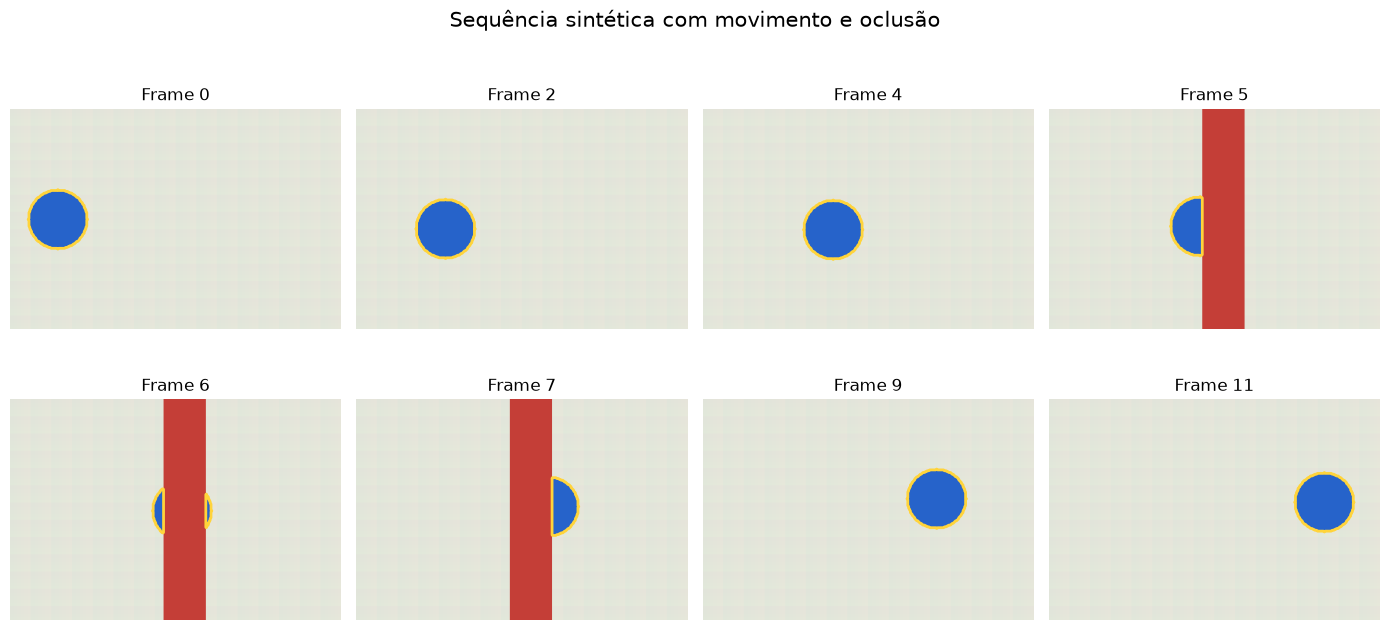

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, index in zip(axes.flat, [0, 2, 4, 5, 6, 7, 9, 11], strict=True):
    ax.imshow(frames[index])
    ax.contour(masks[index], levels=[0.5], colors=["#ffd43b"], linewidths=2)
    ax.set_title(f"Frame {index}")
    ax.axis("off")
fig.suptitle("Sequência sintética com movimento e oclusão", fontsize=15)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "video_demo_contact_sheet.png", dpi=180, bbox_inches="tight")
plt.show()

## Prompts usados

O prompt inicial contém um clique positivo no centro do objeto e um
negativo no fundo. O mesmo par é usado no notebook seguinte para
comparar execução e permitir repetição exata.

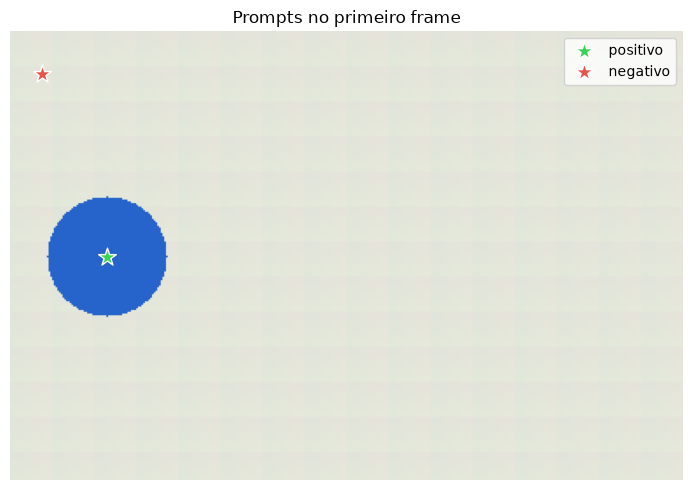

In [4]:
positive_point = np.array([55, 128])
negative_point = np.array([18, 24])

fig, ax = plt.subplots(figsize=(8, 5))
ax.imshow(frames[0])
ax.scatter(*positive_point, c="#39d353", s=180, marker="*", edgecolors="white", label="positivo")
ax.scatter(*negative_point, c="#e5534b", s=180, marker="*", edgecolors="white", label="negativo")
ax.legend()
ax.axis("off")
ax.set_title("Prompts no primeiro frame")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "video_demo_prompts.png", dpi=180, bbox_inches="tight")
plt.show()

## Dados reais

Para substituir o exemplo, extraia um vídeo em frames JPEG numerados e
coloque-os em outro subdiretório de `data/raw/`. O predictor oficial
espera que todos tenham o mesmo tamanho. Máscaras PNG com os mesmos
nomes permitem calcular IoU; sem referência, a análise será apenas
qualitativa.